# Part F – Hyperparameter Tuning & Model Optimization

Tasks Covered:

20. Apply **RandomizedSearchCV** for hyperparameter tuning of:
   - Decision Tree Classifier
   - Random Forest Classifier

21. Select the **best model** based on cross-validation performance.

22. Apply **GridSearchCV** on the best model for deeper fine-tuning.

23. Compare:
   - Untuned vs Tuned model performance
   - Accuracy, Precision, Recall, F1-score, AUC-ROC
   - Best hyperparameters and final conclusion


## 1) Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)


In [2]:
df = pd.read_csv('Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (4600, 19)


,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


## 2) Data Preparation

- Convert date columns into year/month/day
- Encode categorical columns
- Split into train and test sets
- Apply KNN Imputer


In [3]:
# Convert date columns if present
date_cols = [c for c in df.columns if 'date' in c.lower()]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day
    df.drop(columns=[col], inplace=True)

# Encode categorical columns
df_encoded = df.copy()
categorical_cols = df_encoded.select_dtypes(include='object').columns

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

target = 'risk_status'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print("Target:", target)
print("Feature Shape:", X.shape)


Target: risk_status
Feature Shape: (4600, 20)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

imputer = KNNImputer(n_neighbors=5)

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

print("Train Shape:", X_train_imputed.shape)
print("Test Shape :", X_test_imputed.shape)


Train Shape: (3680, 20)
Test Shape : (920, 20)


## 3) Helper Function for Evaluation

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),

        "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
        "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),

        "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),

        "Train F1": f1_score(y_train, y_train_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_test_pred, zero_division=0),

        "Train AUC": roc_auc_score(y_train, y_train_prob),
        "Test AUC": roc_auc_score(y_test, y_test_prob)
    }

    return results, y_test_pred


## 4) Baseline Untuned Models

In [6]:
# Baseline Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)
dt_base_results, dt_base_pred = evaluate_model(
    dt_base, X_train_imputed, y_train, X_test_imputed, y_test,
    model_name="Decision Tree (Untuned)"
)

# Baseline Random Forest
rf_base = RandomForestClassifier(random_state=42)
rf_base_results, rf_base_pred = evaluate_model(
    rf_base, X_train_imputed, y_train, X_test_imputed, y_test,
    model_name="Random Forest (Untuned)"
)

baseline_df = pd.DataFrame([dt_base_results, rf_base_results])
baseline_df


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,Decision Tree (Untuned),1.0,0.969565,1.0,0.880734,1.0,0.864865,1.0,0.872727,1.0,0.924398
1,Random Forest (Untuned),1.0,0.996739,1.0,1.000000,1.0,0.972973,1.0,0.986301,1.0,0.999933


# Task 20 – RandomizedSearchCV for Decision Tree and Random Forest

We use **RandomizedSearchCV** to quickly search a wide hyperparameter space.


In [7]:
# Hyperparameter grid for Decision Tree
dt_param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

dt_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

dt_random.fit(X_train_imputed, y_train)

print("Best Decision Tree Parameters:")
print(dt_random.best_params_)
print("Best CV Score:", dt_random.best_score_)


Best Decision Tree Parameters:
{'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'criterion': 'entropy'}
Best CV Score: 0.8926800062837383


In [8]:
# Hyperparameter grid for Random Forest
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_imputed, y_train)

print("Best Random Forest Parameters:")
print(rf_random.best_params_)
print("Best CV Score:", rf_random.best_score_)


Best Random Forest Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'criterion': 'log_loss', 'bootstrap': False}
Best CV Score: 0.9641926275472874


## 5) Evaluate Best Models from RandomizedSearchCV

In [9]:
dt_tuned_random = dt_random.best_estimator_
rf_tuned_random = rf_random.best_estimator_

dt_tuned_results, dt_tuned_pred = evaluate_model(
    dt_tuned_random, X_train_imputed, y_train, X_test_imputed, y_test,
    model_name="Decision Tree (RandomizedSearchCV)"
)

rf_tuned_results, rf_tuned_pred = evaluate_model(
    rf_tuned_random, X_train_imputed, y_train, X_test_imputed, y_test,
    model_name="Random Forest (RandomizedSearchCV)"
)

randomized_df = pd.DataFrame([dt_tuned_results, rf_tuned_results])
randomized_df


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,Decision Tree (RandomizedSearchCV),0.992663,0.980435,0.979405,0.926606,0.959641,0.909910,0.969422,0.918182,0.999692,0.991654
1,Random Forest (RandomizedSearchCV),1.000000,0.998913,1.000000,1.000000,1.000000,0.990991,1.000000,0.995475,1.000000,1.000000


# Task 21 – Select the Best Model

We compare the **best cross-validation scores** from RandomizedSearchCV and choose the stronger model for final tuning using GridSearchCV.


In [10]:
best_cv_scores = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Best CV F1 Score': [dt_random.best_score_, rf_random.best_score_]
})

best_cv_scores


,Model,Best CV F1 Score
0,Decision Tree,0.892680
1,Random Forest,0.964193


In [11]:
if rf_random.best_score_ >= dt_random.best_score_:
    best_model_name = 'Random Forest'
    best_random_model = rf_random.best_estimator_
else:
    best_model_name = 'Decision Tree'
    best_random_model = dt_random.best_estimator_

print("Best model selected for GridSearchCV:", best_model_name)


Best model selected for GridSearchCV: Random Forest


# Task 22 – GridSearchCV on the Best Model

GridSearchCV performs a **more detailed search** around the best model.


In [12]:
if best_model_name == 'Random Forest':
    grid_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }

    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=grid_params,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

else:
    grid_params = {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [3, 5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [None, 'sqrt', 'log2']
    }

    grid_search = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=grid_params,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

grid_search.fit(X_train_imputed, y_train)

print("Best Parameters from GridSearchCV:")
print(grid_search.best_params_)
print("Best CV Score from GridSearchCV:", grid_search.best_score_)


Best Parameters from GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score from GridSearchCV: 0.9619102081189806


## 6) Final Tuned Model Evaluation

In [13]:
final_tuned_model = grid_search.best_estimator_

final_results, final_pred = evaluate_model(
    final_tuned_model,
    X_train_imputed, y_train,
    X_test_imputed, y_test,
    model_name=f"{best_model_name} (GridSearchCV Final)"
)

pd.DataFrame([final_results])


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,Random Forest (GridSearchCV Final),1.0,0.997826,1.0,1.0,1.0,0.981982,1.0,0.990909,1.0,0.999944


In [14]:
print("Final Tuned Model - Classification Report\n")
print(classification_report(y_test, final_pred))


Final Tuned Model - Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       1.00      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



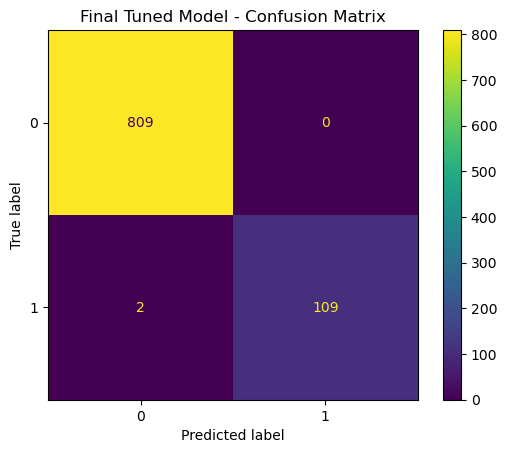

In [15]:
cm_final = confusion_matrix(y_test, final_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_final).plot()
plt.title("Final Tuned Model - Confusion Matrix")
plt.show()


# Task 23 – Compare Untuned vs Tuned Models

In [16]:
all_results = pd.DataFrame([
    dt_base_results,
    rf_base_results,
    dt_tuned_results,
    rf_tuned_results,
    final_results
])

all_results


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,Decision Tree (Untuned),1.000000,0.969565,1.000000,0.880734,1.000000,0.864865,1.000000,0.872727,1.000000,0.924398
1,Random Forest (Untuned),1.000000,0.996739,1.000000,1.000000,1.000000,0.972973,1.000000,0.986301,1.000000,0.999933
2,Decision Tree (RandomizedSearchCV),0.992663,0.980435,0.979405,0.926606,0.959641,0.909910,0.969422,0.918182,0.999692,0.991654
3,Random Forest (RandomizedSearchCV),1.000000,0.998913,1.000000,1.000000,1.000000,0.990991,1.000000,0.995475,1.000000,1.000000
4,Random Forest (GridSearchCV Final),1.000000,0.997826,1.000000,1.000000,1.000000,0.981982,1.000000,0.990909,1.000000,0.999944


In [17]:
comparison_test = all_results[[
    'Model',
    'Test Accuracy',
    'Test Precision',
    'Test Recall',
    'Test F1',
    'Test AUC'
]]

comparison_test.sort_values('Test F1', ascending=False)


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
3,Random Forest (RandomizedSearchCV),0.998913,1.000000,0.990991,0.995475,1.000000
4,Random Forest (GridSearchCV Final),0.997826,1.000000,0.981982,0.990909,0.999944
1,Random Forest (Untuned),0.996739,1.000000,0.972973,0.986301,0.999933
2,Decision Tree (RandomizedSearchCV),0.980435,0.926606,0.909910,0.918182,0.991654
0,Decision Tree (Untuned),0.969565,0.880734,0.864865,0.872727,0.924398


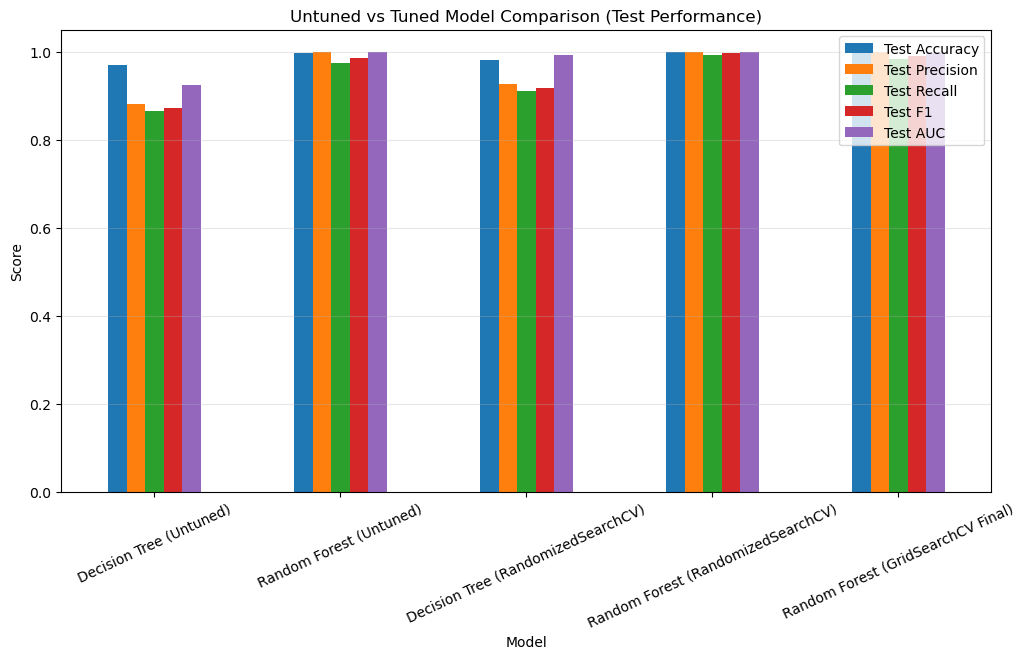

In [18]:
plot_df = comparison_test.set_index('Model')
plot_df.plot(kind='bar', figsize=(12,6))
plt.title("Untuned vs Tuned Model Comparison (Test Performance)")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.grid(axis='y', alpha=0.3)
plt.show()


# Final Interpretation for Part F

## 1. Why Hyperparameter Tuning?
Default parameters do not always give the best performance. Hyperparameter tuning helps find a better model configuration for the dataset.

## 2. RandomizedSearchCV
- Faster than GridSearchCV for large search spaces
- Useful for quickly identifying strong parameter combinations

## 3. GridSearchCV
- Performs a more detailed search
- Applied to the best model selected from RandomizedSearchCV

## 4. Final Comparison
Compare untuned and tuned models using:
- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC

## 5. Business Conclusion
The final tuned model should be selected if it:
- improves **recall** for high-risk customers
- improves **F1-score**
- maintains strong **AUC-ROC**
- generalizes well on unseen test data
